In [2]:
import os
import json
import glob
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoProcessor, LlavaForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [3]:
MODEL_NAME = "llava-hf/llava-1.5-7b-hf"

processor = AutoProcessor.from_pretrained(MODEL_NAME)
model = LlavaForConditionalGeneration.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    max_memory={0: "12GiB", 1: "12GiB"},
)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)

ln_f = model.model.language_model.norm
lm_head = model.lm_head

n_layer = model.config.text_config.num_hidden_layers
hidden_dim = model.config.text_config.hidden_size
print(n_layer, "language model layers,", hidden_dim, "hidden dim")

processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

32 language model layers, 4096 hidden dim


In [4]:
BATCH_DIRS = [
    "/kaggle/input/datasets/nocturnalnerd18/hidden-state-cache-llava-batch1",
    "/kaggle/input/datasets/nocturnalnerd18/hidden-state-cache-llava-batch2",
    "/kaggle/input/datasets/nocturnalnerd18/hidden-state-cache-llava-batch3",
    "/kaggle/input/datasets/nocturnalnerd18/hidden-state-cache-llava-batch4",
    "/kaggle/input/datasets/nocturnalnerd18/hidden-state-cache-llava-batch5",
]

def path_to_image_id(path):
    return os.path.splitext(os.path.basename(path))[0]


all_paths = []
for d in BATCH_DIRS:
    all_paths.extend(glob.glob(os.path.join(d, "*.pt")))

print(len(all_paths), "cached image files found")

350 cached image files found


In [5]:
saved = torch.load("/kaggle/input/datasets/nocturnalnerd18/tuned-lens-llava-all/tuned_lens_llava.pt")
val_ids = set(saved["val_image_ids"])
val_paths = [p for p in all_paths if path_to_image_id(p) in val_ids]
print(len(val_paths), "held-out images recovered from the saved checkpoint")

70 held-out images recovered from the saved checkpoint


In [6]:
class TunedLensTranslators(nn.Module):
    def __init__(self, n_layer, hidden_dim):
        super().__init__()
        self.layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim) for _ in range(n_layer)])
        for layer in self.layers:
            layer.weight.data.copy_(torch.eye(hidden_dim))
            layer.bias.data.zero_()


translators = TunedLensTranslators(n_layer, hidden_dim).to(lm_head.weight.device, torch.float16)
print(sum(p.numel() for p in translators.parameters()), "trainable parameters across", n_layer, "translators")

537001984 trainable parameters across 32 translators


In [8]:
n_layer = saved["n_layer"]
hidden_dim = saved["hidden_dim"]
translators = TunedLensTranslators(n_layer, hidden_dim).to(lm_head.weight.device, torch.float16)
translators.load_state_dict(saved["translators_state_dict"])
translators.eval()

TunedLensTranslators(
  (layers): ModuleList(
    (0-31): 32 x Linear(in_features=4096, out_features=4096, bias=True)
  )
)

In [15]:
@torch.no_grad()
def per_layer_top1_match_rate_by_position(paths, translators, position_type):
    n = n_layer + 1
    match_counts = torch.zeros(n)
    total_counts = torch.zeros(n)
    for path in paths:
        entry = torch.load(path)
        mask = entry["is_image_at_keep"] if position_type == "image" else entry["is_caption_at_keep"]
        target_top1 = entry["target_probs"][mask].argmax(dim=-1)
        for i in range(n):
            h = entry["hidden_states"][i, mask, :].to(lm_head.weight.device, torch.float16)
            if translators is not None and i < n_layer:
                h = translators.layers[i](h)
            if i < n - 1:
                h = ln_f(h)
            lens_top1 = lm_head(h).argmax(dim=-1).cpu()
            match_counts[i] += (lens_top1 == target_top1).sum().item()
            total_counts[i] += target_top1.shape[0]
        del entry
    return (match_counts / total_counts).numpy()

plain_image_rates = per_layer_top1_match_rate_by_position(val_paths, None, "image")
plain_text_rates = per_layer_top1_match_rate_by_position(val_paths, None, "text")
image_rates = per_layer_top1_match_rate_by_position(val_paths, translators, "image")
text_rates = per_layer_top1_match_rate_by_position(val_paths, translators, "text")

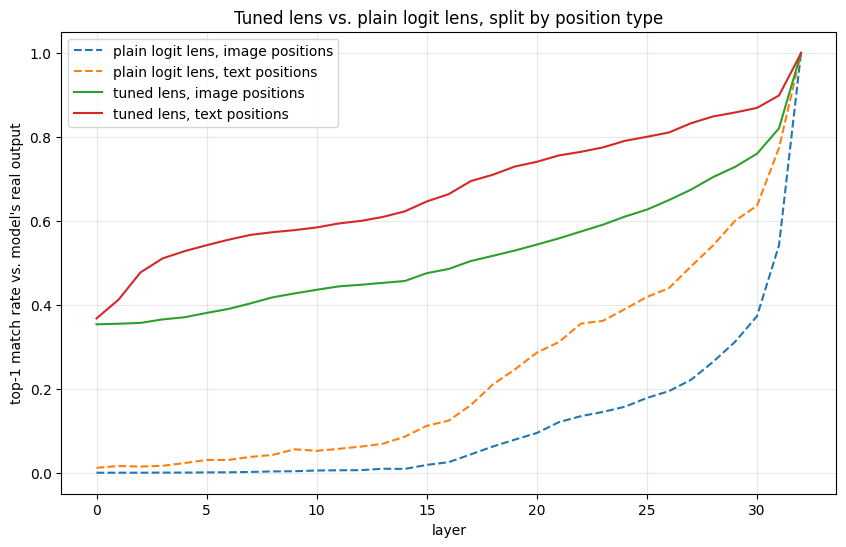

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(plain_image_rates, label="plain logit lens, image positions", linestyle="--")
plt.plot(plain_text_rates, label="plain logit lens, text positions", linestyle="--")
plt.plot(image_rates, label="tuned lens, image positions")
plt.plot(text_rates, label="tuned lens, text positions")
plt.xlabel("layer")
plt.ylabel("top-1 match rate vs. model's real output")
plt.title("Tuned lens vs. plain logit lens, split by position type")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("/kaggle/working/tuned_vs_plain_by_position.png", dpi=150, bbox_inches="tight")
plt.show()